<a href="https://colab.research.google.com/github/PranjalKabra/Fairness-Movie-Recommender/blob/main/Notebook_movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [96]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import zipfile
import math
from sklearn.metrics import accuracy_score, r2_score

In [97]:
print(tf.__version__)

2.20.0


## Unzip the data

In [133]:
zip_path = '/content/dataset_movie.zip'
extract_path = '/content/extracted_data'

if os.path.exists(zip_path):
  if(zipfile.is_zipfile(zip_path)):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      zip_ref.extractall(extract_path)
      ratings_file = os.path.join(extract_path, "u.data")
      user_attribute_file = os.path.join(extract_path, "u.user")


In [134]:
ratings_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv(ratings_file, sep='\t', names=ratings_cols)
ratings = ratings.drop('unix_timestamp', axis=1)
# ratings

In [135]:
user_attributes_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv(user_attribute_file, sep='|', names=user_attributes_cols)
# users

Allot 0 to Male and 1 To female

In [136]:
ratings['count'] = ratings.groupby('user_id')['movie_id'].transform('count')
ratings = ratings[ratings['count'] >= 10]
users['gender'] = users['gender'].map(lambda x: 1 if x == 'F' else 0)
users = users.drop(['age', 'occupation', 'zip_code'], axis=1)

len(ratings['user_id'].unique())

943

In [137]:
df = pd.merge(ratings, users, on='user_id', how='left')
df.head()
# len(df['user_id'].unique())

,user_id,movie_id,rating,count,gender
0,196,242,3,39,0
1,186,302,3,92,1
2,22,377,1,128,0
3,244,51,2,238,0
4,166,346,1,20,0


## Encoding Data for Embeddings

In [138]:
user_ids = df["user_id"].unique().tolist()
movie_ids = df["movie_id"].unique().tolist()

user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)} # For decoding later
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)} # For decoding later

df["users"] = df["user_id"].map(user2user_encoded)
df["movies"] = df["movie_id"].map(movie2movie_encoded)

In [139]:
num_users = len(user_ids)
num_movies = len(movie_ids)
min_rating = min(df['rating'])
max_rating = max(df['rating'])

# df['rating'] = df['rating'].map(lambda x: (x - min_rating)).values

print(f'Number of users: {num_users}')
print(f'Number of movies: {num_movies}')
print(f'Min rating: {min_rating}')
print(f'Max rating: {max_rating}')
print(df.head())

Number of users: 943
Number of movies: 1682
Min rating: 1
Max rating: 5
   user_id  movie_id  rating  count  gender  users  movies
0      196       242       3     39       0      0       0
1      186       302       3     92       1      1       1
2       22       377       1    128       0      2       2
3      244        51       2    238       0      3       3
4      166       346       1     20       0      4       4


## Train & Test Split

In [140]:
df = df.sample(frac=1, random_state=42)
df['rating'] = df['rating'].map(lambda x: (x - min_rating) / (max_rating - min_rating)).values
# xtract input
x = df[["users", "movies"]].values

# xtract targets
y_rating = df["rating"].values
# y_rating = df["rating"].values.map(lambda x: (x - min_rating) / (max_rating - min_rating)).values
y_gender = df["gender"].values

# splitting
train_indices = int(0.9 * df.shape[0])
x_train, x_val = x[:train_indices], x[train_indices:]

In [141]:
# build the massive 7-lists together answer key for Multi-Task Learning!
y_train = [
    y_rating[:train_indices],    # Target 1: Actual Rating
    y_gender[:train_indices],  # Target 2: Gender Biased mlp
    y_gender[:train_indices],  # Target 3: Gender Biased gmf
    y_gender[:train_indices],  # Target 4 :Fair mlp (Goal: Guess WRONG)
    y_gender[:train_indices],   # Target 5: Fair gmf (Goal: Guess WRONG)
    np.zeros(train_indices),    # Target 6: Zeros ub
    np.zeros(train_indices)    # Target 7: Zeros ud
]

y_val = [
    y_rating[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    y_gender[train_indices:],
    np.zeros(df.shape[0]-train_indices),
    np.zeros(df.shape[0]-train_indices)
]

print('x_train shape : ', x_train.shape)
print('x_val shape   : ', x_val.shape)
print(y_train[0][0:50])

x_train shape :  (90000, 2)
x_val shape   :  (10000, 2)
[0.75 0.5  0.75 0.25 0.25 0.5  1.   0.75 0.5  0.75 0.75 0.75 0.5  0.75
 0.5  0.5  0.25 0.5  0.75 0.5  0.75 0.25 0.5  0.5  0.5  1.   0.75 1.
 0.5  1.   0.5  0.75 0.5  0.5  0.5  0.75 0.5  1.   0.75 1.   1.   1.
 0.75 0.25 0.5  0.75 0.5  0.5  0.5  0.25]


## FairRec NeuCF model

In [142]:
EMBEDDING_SIZE = 50

class RecommenderSys(keras.Model):
    def __init__(self, num_users, num_movies, **kwargs):
        super().__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = EMBEDDING_SIZE

        # BIAS-AWARE USER VECTORS (u_b_mlp)
        self.user_embedding_biased_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-AWARE USER VECTORS (u_b_gmf)
        self.user_embedding_biased_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_d_mlp)
        self.user_embedding_fair_mlp = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # BIAS-FREE USER VECTORS (u_d_gmf)
        self.user_embedding_fair_gmf = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings mlp
        self.movie_embedding_mlp = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # movie embeddings gmf
        self.movie_embedding_gmf = layers.Embedding(
            num_movies,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6)
        )

        # mlp for combining user embeddings for mlp and movie embeddings for mlp
        self.mlp = keras.models.Sequential([
            layers.Dense(4*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(2*EMBEDDING_SIZE, activation='relu'),
            layers.Dense(EMBEDDING_SIZE),
        ])

        # NN(no hidden layers) to combine mlp and gmf outputs
        self.neuCF = layers.Dense(1)

        # NNs(no hdden layers)  (To predict Gender)
        self.att_predictor_mlp = layers.Dense(1)
        self.att_predictor_gmf = layers.Dense(1)

        # NNs(no hdden layers)  (To discriminate Gender)
        self.att_discriminator_mlp = layers.Dense(1)
        self.att_discriminator_gmf = layers.Dense(1)

    def call(self, inputs):
        # get the user embeddings
        u_b_mlp = self.user_embedding_biased_mlp(inputs[:, 0])
        u_b_gmf = self.user_embedding_biased_gmf(inputs[:, 0])
        u_f_mlp = self.user_embedding_fair_mlp(inputs[:, 0])
        u_f_gmf = self.user_embedding_fair_gmf(inputs[:, 0])

        # get themovie embeddings
        m_mlp = self.movie_embedding_mlp(inputs[:, 1])
        m_gmf = self.movie_embedding_gmf(inputs[:, 1])

        # combining fair and biased user embeddings(u = ub + uf)
        u_mlp = tf.add(u_b_mlp, u_f_mlp)
        u_gmf = tf.add(u_b_gmf, u_f_gmf)

        # make the prediction layer for gmf and mlp
        gmf_layer = tf.multiply(u_gmf, m_gmf)
        mlp_layer = self.mlp(tf.concat([u_mlp, m_mlp], axis = 1))

        # final predicted rating
        predicted_rating = self.neuCF(tf.concat([gmf_layer, mlp_layer], 1))

        # gender predictor
        z_b_mlp = self.att_predictor_mlp(u_b_mlp) # z cap
        z_b_gmf = self.att_predictor_gmf(u_b_gmf)  # z tilda

        # gender discrimator
        z_f_gmf = self.att_discriminator_gmf(u_f_gmf)
        z_f_mlp = self.att_discriminator_mlp(u_f_mlp)

        # compute orthogonality loss which should be minimized btwn u_b and u_f
        ortho_loss_mlp = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_mlp, u_f_mlp])
        ortho_loss_gmf = tf.keras.layers.Dot(axes=1, normalize=True)([u_b_gmf, u_f_gmf])

        # the sigmoid activation forces the rating to between 0 and 1
        return [
            predicted_rating,
            tf.nn.sigmoid(z_b_mlp),
            tf.nn.sigmoid(z_b_gmf),
            tf.nn.sigmoid(z_f_mlp),
            tf.nn.sigmoid(z_f_gmf),
            ortho_loss_mlp,
            ortho_loss_gmf
        ]

## Loss func

In [143]:
def neg_binary_crossentropy(y_true, y_pred):
    return -1.0 * keras.losses.binary_crossentropy(y_true, y_pred)

def root_mean_squared_error(y_true, y_pred):
    return keras.backend.sqrt(keras.backend.mean(keras.backend.square(y_pred - y_true)))

In [144]:
model = RecommenderSys(num_users, num_movies)
model.compile(
    loss=[root_mean_squared_error, tf.keras.losses.BinaryCrossentropy(), tf.keras.losses.BinaryCrossentropy(), neg_binary_crossentropy, neg_binary_crossentropy, tf.keras.losses.MeanSquaredError(), tf.keras.losses.MeanSquaredError()],
    loss_weights=[1,0.5,0.5,0.5,0.5,0.5,0.5],
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
)

## Train

In [145]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=7,
    verbose=1,
    validation_data=(x_val, y_val),
)

Epoch 1/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - binary_crossentropy_loss: 0.1084 - loss: -25.4531 - mean_squared_error_loss: 0.0014 - neg_binary_crossentropy_loss: -27.5881 - root_mean_squared_error_loss: 0.2493 - val_binary_crossentropy_loss: 0.0046 - val_loss: -75.8351 - val_mean_squared_error_loss: 4.8098e-05 - val_neg_binary_crossentropy_loss: -78.6279 - val_root_mean_squared_error_loss: 0.2370
Epoch 2/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_crossentropy_loss: 0.0021 - loss: -164.0991 - mean_squared_error_loss: 1.2712e-05 - neg_binary_crossentropy_loss: -167.3142 - root_mean_squared_error_loss: 0.2359 - val_binary_crossentropy_loss: 9.6361e-04 - val_loss: -268.4909 - val_mean_squared_error_loss: 3.3906e-06 - val_neg_binary_crossentropy_loss: -271.8417 - val_root_mean_squared_error_loss: 0.2377
Epoch 3/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_crossentropy_loss: 6.1936e-04 - loss: -401.2611 - mean_squared_error_loss: 3.0436e-06 - neg_binary_crossent

In [146]:
model.evaluate(x_val, y_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_crossentropy_loss: 8.7309e-05 - loss: -2371.0237 - mean_squared_error_loss: 3.1756e-04 - neg_binary_crossentropy_loss: -2378.0544 - root_mean_squared_error_loss: 0.2351


[-2371.023681640625,
 0.23506540060043335,
 8.730941044632345e-05,
 8.730941044632345e-05,
 -2378.054443359375,
 -2378.054443359375,
 0.00031755759846419096,
 0.00031755759846419096]

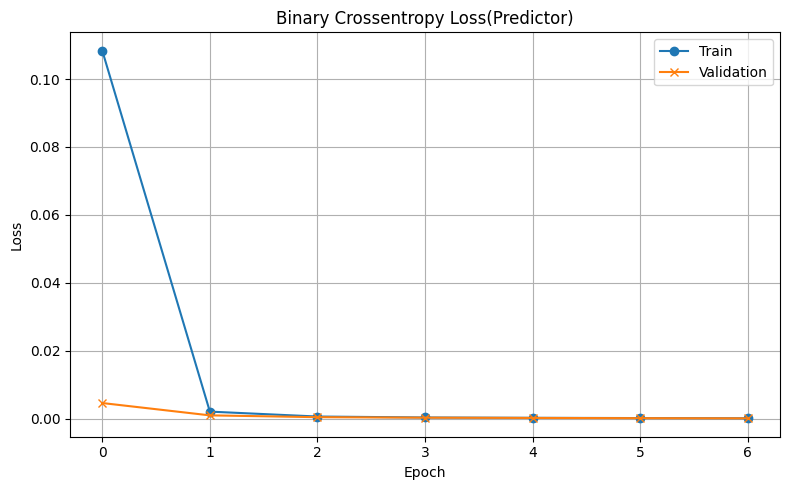

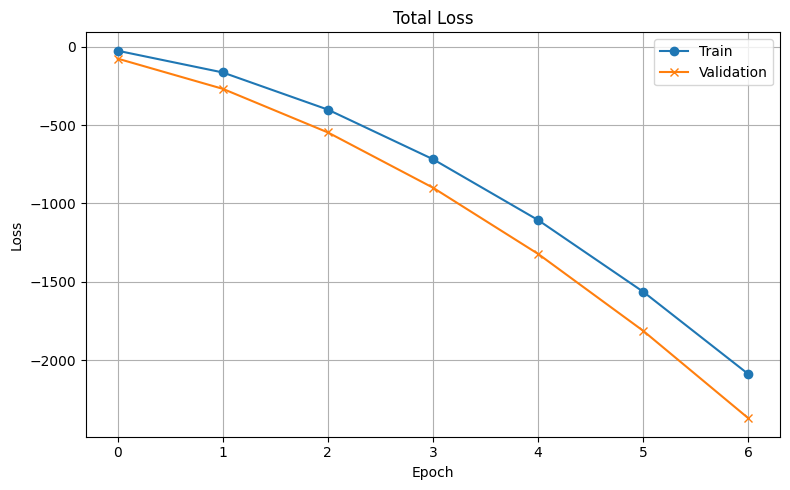

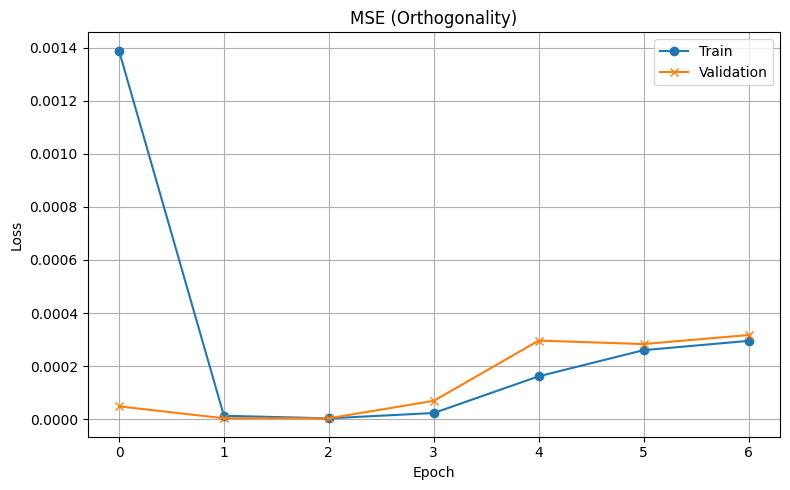

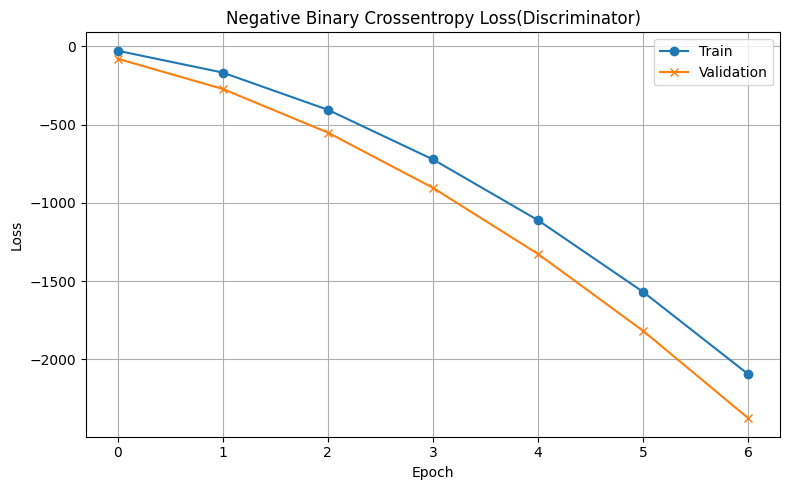

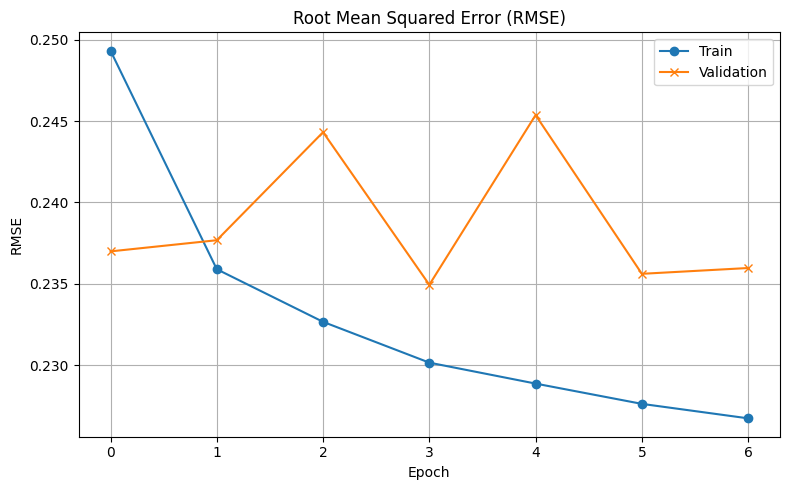

In [147]:
def plot_metrics(history, key, title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[key], marker='o', label='Train')
    plt.plot(history.history["val_" + key], marker='x', label='Validation')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the plot function for each metric
plot_metrics(history, "binary_crossentropy_loss", "Binary Crossentropy Loss(Predictor)", "Loss")
plot_metrics(history, "loss", "Total Loss", "Loss")
plot_metrics(history, "mean_squared_error_loss", "MSE (Orthogonality)", "Loss")
plot_metrics(history, "neg_binary_crossentropy_loss", "Negative Binary Crossentropy Loss(Discriminator)", "Loss")
plot_metrics(history, "root_mean_squared_error_loss", "Root Mean Squared Error (RMSE)", "RMSE")

# Unified User embeddings

In [148]:
# UNIFIED USER EMBEDDINGS

ub_mlp_w = np.array(model.user_embedding_biased_mlp.get_weights())
ub_gmf_w = np.array(model.user_embedding_biased_gmf.get_weights())
# print(np.shape(model.user_embedding_biased_mlp.get_weights()))
uf_mlp_w = np.array(model.user_embedding_fair_mlp.get_weights())
uf_gmf_w = np.array(model.user_embedding_fair_gmf.get_weights())

unified_user_embedding = layers.Embedding(
            num_users,
            EMBEDDING_SIZE,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
        )

output = unified_user_embedding(x_train[:,0])
# print(np.shape(unified_user_embedding.get_weights()))
w_mlp = np.add(ub_mlp_w, uf_mlp_w)
w_gmf = np.add(ub_gmf_w, uf_gmf_w)
w = np.add(w_mlp,w_gmf)
unified_user_embedding.set_weights(w)

# print(w.shape)

In [149]:
# TESTING

movies_embedding = model.movie_embedding_mlp
uv = model.user_embedding_biased_mlp(x_train[:,0])
mv = movies_embedding(x_train[:,1])
scores = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1])

mse = tf.keras.losses.MeanSquaredError()
mse(y_train[0], scores).numpy()

np.float32(0.49888402)

In [150]:
movie_df = pd.read_csv('/content/extracted_data/u.item', sep='|', header=None, encoding='latin-1')
movie_df = movie_df[[0, 1]]
movie_df.columns = ['movie_id', 'title']
movie_df.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [151]:
# TOP 10 FAIRNESS AWARE MOVIE RECOMMENDATIONS FOR A RANDOM USER USING BIAS-FREE EMBEDDINGS

user_id = df.user_id.sample(1).iloc[0] # Keep this in another cell else random user will change each time the cell runs
# user_id = 234
movies_watched_by_user = df[df.user_id == user_id]
movies_not_watched = movie_df[~movie_df['movie_id'].isin(movies_watched_by_user.movie_id.values)]['movie_id']
movies_not_watched = list(
    set(movies_not_watched).intersection(set(movie2movie_encoded.keys()))
)
movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]

user_encoder = user2user_encoded.get(user_id)
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched)
)

# print('len : ',len(user_movie_array))
uv = unified_user_embedding(user_movie_array[:,0])
mv = movies_embedding(user_movie_array[:,1])
ratings = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1]).numpy()
# print(ratings)

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [
    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices
]

print("Showing recommendations for user: {}".format(user_id))
print("====" * 9)
print("Movies with high ratings from user")
print("----" * 8)
top_movies_user = (
    movies_watched_by_user.sort_values(by="rating", ascending=False)
    .head(5)
    .movie_id.values
)
movie_df_rows = movie_df[movie_df["movie_id"].isin(top_movies_user)]
for row in movie_df_rows.itertuples():
    print(row.title)

print("----" * 8)
print("Top 10 movie recommendations")
print("----" * 8)
recommended_movies = movie_df[movie_df["movie_id"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(row.title)

Showing recommendations for user: 100
Movies with high ratings from user
--------------------------------
Good Will Hunting (1997)
Titanic (1997)
Apt Pupil (1998)
As Good As It Gets (1997)
Seven Years in Tibet (1997)
--------------------------------
Top 10 movie recommendations
--------------------------------
Flipper (1996)
Turbo: A Power Rangers Movie (1997)
Showgirls (1995)
Beverly Hills Ninja (1997)
Kull the Conqueror (1997)
Wishmaster (1997)
Casper (1995)
Bloodsport 2 (1995)
Madonna: Truth or Dare (1991)
Trial and Error (1997)


In [22]:
# # Evaluation

# uv = unified_user_embedding(x_val[:,0])
# mv = movies_embedding(x_val[:,1])
# ratings = tf.reshape(tf.reduce_sum( tf.multiply( uv, mv ), 1, keepdims=True ),[-1]).numpy()


In [23]:
# print(ratings)
# ratings = 0.5*ratings
# print(ratings)
# ratings = tf.nn.sigmoid(ratings)
# # print(len(y_val[0]), len(ratings))
# # print(y_val[0])
# # print(ratings)

# rmse = tf.keras.metrics.RootMeanSquaredError()
# rmse.update_state(y_val[0],ratings)
# print('RMSE : ',rmse.result().numpy())
# r2 = r2_score(y_val[0], np.array(ratings)) # Tells whether Model explains the variance in the dataset (1 -> perfect, 0 -> same as predicting mean for all, negative -> worse)
# print('Coefficient of Determination : ',r2)

[-0.04962818 -0.6281673  -1.2608384  ... -0.92300427  0.70401275
 -0.8365361 ]
[-0.02481409 -0.31408364 -0.6304192  ... -0.46150213  0.35200638
 -0.41826805]
RMSE :  3.0549223
Coefficient of Determination :  -6.1314778327941895


In [152]:
predictions = model.predict(x_val)
predicted_ratings = predictions[0]
predicted_ratings

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


array([[0.3655933 ],
       [0.69734234],
       [0.41492963],
       ...,
       [0.7536575 ],
       [0.48381788],
       [0.6470203 ]], dtype=float32)

In [153]:
y_val[0]

array([0.5 , 0.75, 0.75, ..., 0.5 , 0.5 , 0.5 ])

In [154]:
from sklearn.metrics import r2_score
import numpy as np

# Print the true shape and a preview to verify
print("True Ratings: ", y_val[0][:5])
print("Predicted Ratings: ", np.reshape(predicted_ratings[:5], [-1]))

# Calculate R2 & RMSE
r2 = r2_score(y_val[0], predicted_ratings)
print('Actual Coefficient of Determination (R2): ', r2)

rmse = tf.keras.metrics.RootMeanSquaredError()
rmse.update_state(y_val[0],predicted_ratings)
print('RMSE : ',rmse.result().numpy())
# r2m = r2_score(y_val[0], np.array(predicted_ratings)) # Tells whether Model explains the variance in the dataset (1 -> perfect, 0 -> same as predicting mean for all, negative -> worse)
# print('Coefficient of Determination : ',r2m)

True Ratings:  [0.5  0.75 0.75 0.75 0.25]
Predicted Ratings:  [0.3655933  0.69734234 0.41492963 0.7438403  0.62227815]
Actual Coefficient of Determination (R2):  0.3021638874666286
RMSE :  0.23704101


## Testing Fairness

In [155]:

discriminator = keras.Sequential([
    layers.Input(shape=(EMBEDDING_SIZE,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

gender_labels = []
for key in userencoded2user:
    gender_labels.append(df.loc[df["users"] == key, "gender"].values[0])
gender_labels = np.array(gender_labels).astype(int)

# len(gender_labels)
biased_embeddings = np.array(ub_mlp_w[0])
fair_embeddings = np.array(uf_mlp_w[0])
# print(fair_embeddings.shape, len(gender_labels))
history = discriminator.fit(biased_embeddings, gender_labels, epochs=10, batch_size=32)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9470 - loss: 0.5294
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2612
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.1116
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0522
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0291
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0184
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0128
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0094
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0072
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0057


WE want to minimize the score here.
if a user's movie tastes are perfectly stripped of gender, the Detective shouldn't be able to guess 0 (Male) or 1 (Female). It should be completely confused and guess a 50/50 coin toss (0.5).

x - 0.5: We look at every single guess (x) and subtract 0.5 to see how far away the Detective was from total confusion.

In [156]:
gender_predictions = discriminator.predict(fair_embeddings)
score = 0
for x in gender_predictions:
    score += abs(x-0.5)

score /= len(gender_predictions)
print(score)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[0.47550067]


In [157]:
yr = model.predict(x_val)[0]
yr.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(10000, 1)

In [123]:
from collections import defaultdict

e = Expectation (or Average)

g = Group (Female)

neg_g = Negative Group (Male)

y = Predicted Rating (from the neural network)

r = Real Rating (the true ground-truth stars)

j = Item/Movie ID

e_g_y_j_all: All Predicted ratings (y) for a movie (j) made by Females (g).

e_g_r_j_all: All Real ratings (r) for a movie (j) made by Females (g).

e_neg_g_y_j_all: All Predicted ratings (y) for a movie (j) made by Males (neg_g).

e_neg_g_r_j_all: All Real ratings (r) for a movie (j) made by Males (neg_g).

In [159]:
e_g_y_j_all = defaultdict(list)
e_neg_g_y_j_all = defaultdict(list)
e_g_r_j_all = defaultdict(list)
e_neg_g_r_j_all = defaultdict(list)

# print("---",np.count_nonzero(y_val[1]==1))
# print(x_val.shape)
for i in range(len(x_val)):
    if(y_val[1][i] == 1): #female
        e_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_g_r_j_all[x_val[i][1]].append(y_val[0][i])
    if(y_val[1][i] == 0): #male
        e_neg_g_y_j_all[x_val[i][1]].append(yr[i][0])
        e_neg_g_r_j_all[x_val[i][1]].append(y_val[0][i])

In [160]:
e_g_y_j = {}
e_neg_g_y_j = {}
e_g_r_j = {}
e_neg_g_r_j = {}
for k in e_g_y_j_all:
  e_g_y_j[k] = np.nanmean(e_g_y_j_all[k])
for k in e_g_r_j_all:
  e_g_r_j[k] = np.nanmean(e_g_r_j_all[k])
for k in e_neg_g_y_j_all:
  e_neg_g_y_j[k] = np.nanmean(e_neg_g_y_j_all[k])
for k in e_neg_g_r_j_all:
  e_neg_g_r_j[k] = np.nanmean(e_neg_g_r_j_all[k])
# print(e_g_y_j)

In [161]:
movies = set(x_val[:,1])
l = len(movies)
# print(l)

def safe_val(d, key):
    val = d.get(key, 0)
    return 0 if val is None or np.isnan(val) else val

val_score, abs_score, over_est, under_est = 0.0, 0.0, 0.0, 0.0

for movie in movies:
    eg_y = safe_val(e_g_y_j, movie)
    eg_r = safe_val(e_g_r_j, movie)
    eng_y = safe_val(e_neg_g_y_j, movie)
    eng_r = safe_val(e_neg_g_r_j, movie)

    val_score += np.abs((eg_y - eg_r) - (eng_y - eng_r))
    abs_score += np.abs(np.abs(eg_y - eg_r) - np.abs(eng_y - eng_r))
    over_est += np.abs(np.maximum(0, eg_y - eg_r) - np.maximum(0, eng_y - eng_r))
    under_est += np.abs(np.maximum(0, eg_r - eg_y) - np.maximum(0, eng_r - eng_y))

val_score /= l
abs_score /= l
over_est /= l
under_est /= l

print(val_score, abs_score, over_est, under_est)

0.1692341408572589 0.13264470681441468 0.09110938826884518 0.07812475258841352
